# TODO LIST
## 1. INDEKSY DO SPRADZENIA

In [1001]:
from typing import Union

import matplotlib.pyplot as plt
import numpy as np
from keras.datasets import mnist
from tqdm import tqdm
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

Loads the MNIST dataset.  This is a dataset of 60,000 28x28 grayscale images of the 10 digits, along with a test set of 10,000 images. More info can be found at the [MNIST homepage](http://yann.lecun.com/exdb/mnist/).

Args: path: path where to cache the dataset locally (relative to `~/.keras/datasets`).

Returns: Tuple of NumPy arrays: `(x_train, y_train), (x_test, y_test)`.

**`x_train`**: `uint8` NumPy array of grayscale image data with shapes `(60000, 28, 28)`, containing the training data. Pixel values range from 0 to 255.

**`y_train`**: `uint8` NumPy array of digit labels (integers in range 0-9) with shape `(60000,)` for the training data.

**`x_test`**: `uint8` NumPy array of grayscale image data with shapes `(10000, 28, 28)`, containing the test data. Pixel values range from 0 to 255.

**`y_test`**: `uint8` NumPy array of digit labels (integers in range 0-9) with shape `(10000,)` for the test data.  

In [1002]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

In [1003]:
# Normalization of data
x_train = x_train.astype(np.float32) / 255.0
x_test = x_test.astype(np.float32) / 255.0

In [1004]:
input_index = 0  # Index of an input
x_train[input_index]

array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.    

Label: 5


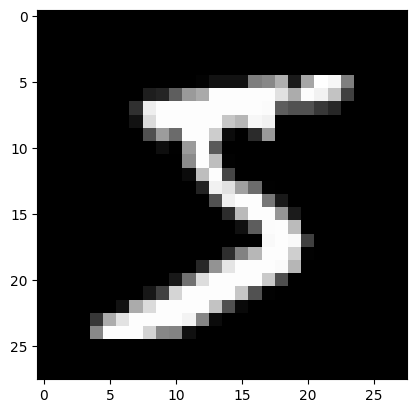

In [1005]:
# Print label and show image
y_target = y_train[input_index]
print("Label:", y_target)
plt.imshow(x_train[input_index], cmap="gray")
plt.show()

In [1006]:
input_size = x_train.shape[1] * x_train.shape[2]
output_size = 10
print(input_size)

784


In [1007]:
# Flatten: reshape each 28x28 image into a 784 vector
x_train = x_train.reshape(x_train.shape[0], -1)
x_test = x_test.reshape(x_test.shape[0], -1)

print("Flattened shape (train):", x_train.shape)
print("Flattened shape (test):", x_test.shape)

Flattened shape (train): (60000, 784)
Flattened shape (test): (10000, 784)


In [1008]:
x = x_train[input_index]

Define $x$ as an input column vector of size $n_0$

# Model Params
$L$ - number of layers

For $i = 1, \ldots, L$:

$n_i$ - number of neurons in i-th layer ($n_0$ - input size)


$$w^{(i)} =
\begin{bmatrix}
w_{11} & \cdots & w_{1n_{i-1}} \\
\vdots & \ddots & \vdots \\
w_{n_{i}1} & \cdots & w_{n_{i}n_{i-1}}
\end{bmatrix} - ($n_i \times n_{i-1}) \text{ weight matrix}$$

$$b^{(i)} = \begin{bmatrix}
b_{1}\\
\vdots\\
b_{n_{i}}
\end{bmatrix}  \text{ - bias vector}$$

$$z^{(1)} = w^{(1)}x+b^{(1)}$$

$$\sigma^{(i)} \colon \mathbb{R}^{n_i} \to \mathbb{R}^{n_i}$$

$$a^{(i)} = \sigma^{(i)} (z^{(i)})$$

$$z^{(i)} = w^{(i)} a^{(i - 1)}+b^{(i)}$$

$$C_x \colon \mathbb{R}^{n_0} \to \mathbb{R} \text{ - cost function value for input x}$$

$$\frac{\partial C_x}{\partial w_{ij}} = \frac{\partial C_x}{\partial z_{j}}  \frac{\partial z_j}{\partial w_{ij}}$$

$$\frac{\partial C_x}{\partial z_{j}} = \delta_j$$

$$\frac{\partial z_j}{\partial w_{ij}} = x_i$$


### Softmax Function

$$\sigma(z)_i = \frac{e^{z_i}}{\sum_{j} e^{z_j}$$

### Equivalentily 

$$\sigma(z)_i = \frac{e^{z_i - c}}{\sum_{j} e^{z_j - c}$$


$$ \text{for }c = \max_{j}z_j$$  

In [1009]:
def softmax(z):
    c = np.max(z)
    exp_list = np.array([np.exp(z_i - c) for z_i in z])
    return exp_list / sum(exp_list)

## test
print(softmax(np.array([1, 2, 8])))

[9.08800555e-04 2.47037604e-03 9.96620823e-01]


In [1010]:
def delta(z, true_label):
    return [softmax(z)[j] - (j == true_label) for j in range(len(z))]

## test
z = np.array([0.1, 0.3])
print(delta(z, 0))
# [-0.55, 0.55]

[np.float64(-0.549833997312478), np.float64(0.549833997312478)]


In [1011]:
def categorical_cross_entropy(pred_output: np.ndarray, true_label: int) -> int:
    """
    Computes categorical cross-entropy loss for single-label multi-class classification tasks.

    Parameters
    ----------
    pred_output : np.ndarray
    Predicted probability distribution over classes (output of softmax).
    
    true_label : int
        Index of the correct class.

    Returns
    -------
    float
        Negative log-likelihood of the correct class prediction.

    Notes
    -----
    Uses log-stabilization to avoid numerical issues.
    """
    return -np.log(pred_output[true_label])

In [1012]:
np.random.seed(666)


class NeuralNetwork():
    def __init__(self, layer_sizes):
        self.layer_sizes = layer_sizes
        self.L = len(layer_sizes) - 1  ## number of all layers except of input layer
        self.biases = [np.random.randn(layer) for layer in layer_sizes[1:]]
        self.weights = [np.random.randn(layer_sizes[i + 1], layer_sizes[i])
                        for i in range(self.L)]

    def z(self, input):
        return [np.dot(self.weights[layer], input) + self.biases[layer]
                for layer in range(self.L)]

    def activation_output(self, input, layer, activation_function):
        return activation_function(self.z(input)[layer])

    def train(self, input, delta, learning_rate=0.1):
        # for input in inputs:
        for layer in range(self.L):
            for j in range(output_size):
                self.biases[layer][j] -= learning_rate * delta[j]
                for i in range(self.layer_sizes[layer]):
                    self.weights[layer][j][i] -= learning_rate * delta[j] * input[i]


In [1013]:
def pretty_softmax(
        probs: Union[np.ndarray, list],
        true_label: int,
        
        bar_length: int = 25
) -> None:
    # Konwersja do numpy array (bezpieczna obsługa list)
    probs = np.asarray(probs).reshape(-1)

    # Stabilna normalizacja wizualizacji (dla bezpieczeństwa)
    max_prob = np.max(probs) if np.max(probs) > 0 else 1.0

    print("\n┌────────┬───────────────┬─────────────────────────┐")
    print("│ class  │ probability   │ visualization           │")
    print("├────────┼───────────────┼─────────────────────────┤")

    for i, p in enumerate(probs):
        # skalowanie paska względem największej wartości
        bar = "█" * int((p / max_prob) * bar_length)

        print(f"│ {i:<6} │ {p:.10f} │ {bar:<23} │")

    print("└────────┴───────────────┴─────────────────────────┘")

    # Predykcja
    pred_class = int(np.argmax(probs))
    pred_conf = float(probs[pred_class])

    print("\n PREDYKCJA MODELU")
    print(f"   → klasa: {pred_class}")
    print(f"   → pewność: {pred_conf * 100:.2f}%")
    
    cce = categorical_cross_entropy(probs, true_label)
    print(f"\nCategorical Cross Entropy Loss Function : {cce:.2f}")

## Loss Function (Cross-Entropy)

$$C_x = -\log(\sigma(z))_t \text{ for a true lebel } t=y(x)$$


In [1014]:
# TEST

NN = NeuralNetwork(layer_sizes=[input_size, output_size])

y_output = NN.activation_output(input=x, layer=0, activation_function=softmax)
pretty_softmax(y_output, true_label=y_target)


┌────────┬───────────────┬─────────────────────────┐
│ class  │ probability   │ visualization           │
├────────┼───────────────┼─────────────────────────┤
│ 0      │ 0.0000000000 │                         │
│ 1      │ 0.8831093377 │ █████████████████████████ │
│ 2      │ 0.0000017424 │                         │
│ 3      │ 0.0000000010 │                         │
│ 4      │ 0.0810302356 │ ██                      │
│ 5      │ 0.0000000000 │                         │
│ 6      │ 0.0358564688 │ █                       │
│ 7      │ 0.0000000004 │                         │
│ 8      │ 0.0000000148 │                         │
│ 9      │ 0.0000021993 │                         │
└────────┴───────────────┴─────────────────────────┘

 PREDYKCJA MODELU
   → klasa: 1
   → pewność: 88.31%

Categorical Cross Entropy Loss Function : 25.31


In [1015]:
print(y_output)
categorical_cross_entropy(pred_output=y_output, true_label=y_target)

[2.75286196e-12 8.83109338e-01 1.74236764e-06 9.61410984e-10
 8.10302356e-02 1.01578328e-11 3.58564688e-02 4.07405908e-10
 1.48418845e-08 2.19925308e-06]


np.float64(25.31277600654298)

In [1016]:
NN.weights[0].shape

(10, 784)

In [1017]:
NN.weights[0]

array([[ 0.60886999, -0.93101185,  0.97822225, ...,  0.23471696,
         0.90366397, -0.30436648],
       [-0.8137819 ,  0.93930598,  0.86878845, ...,  1.29449034,
         0.65276704, -1.71334967],
       [-0.54084734,  1.78390204,  0.61701591, ...,  1.66648529,
         0.87448054,  2.12376334],
       ...,
       [-0.23676761, -0.56508953,  1.51203671, ...,  0.08855362,
        -0.23287575,  0.54671023],
       [-1.91401418,  0.76135899,  0.0838658 , ..., -0.48462293,
         1.67801487, -1.14390422],
       [ 1.97922032,  1.39529597, -0.35872259, ..., -0.00615919,
         0.25350913,  0.38972457]], shape=(10, 784))

###  Categorical-Cross Entropy and Softmax Activation Function Partial Derivative

$t$ - real label
$y_j = 
\begin{cases}
    1 
    & \text{ if } j = t\\
    0  & \text{ if } j \neq t
\end{cases}
=
$ - 1-hot encoded target vector

$$C = - \log(\sigma(z)_t) = - \log(\frac{e^{z_t}}{\sum_k e^{z_k}}) = \log(\sum_k e^{z_k}) - z_t$$

For $j = t$:

$$\frac{\partial C}{\partial z_{t}} = 

    \frac{e^{z_t}}{\sum_{k}e^{z_k}} - 1 =  
    \sigma(z)_t - 1
$$

For $j \neq t$:

$$\frac{\partial C}{\partial z_{j}} = \sigma(z)_j$$

For all $j$
$$\frac{\partial C}{\partial z_{j}} = \sigma(z)_j - y_j$$

In [1018]:
z_0 = NN.z(x)[0]
z_0

array([-9.78696801, 16.70710576,  3.57114636, -3.93120712, 14.3184791 ,
       -8.48136399, 13.50318073, -4.78979909, -1.1944006 ,  3.80401926])

In [1019]:
delta_0 = delta(z_0, y_target)
delta_0

[np.float64(2.7528619601496656e-12),
 np.float64(0.8831093377474095),
 np.float64(1.7423676386396015e-06),
 np.float64(9.614109838562934e-10),
 np.float64(0.0810302355740711),
 np.float64(-0.9999999999898421),
 np.float64(0.03585646883418486),
 np.float64(4.074059077186295e-10),
 np.float64(1.4841884506862953e-08),
 np.float64(2.1992530838346083e-06)]

In [1020]:
NN.train(input=x, delta=delta_0, learning_rate=0.1)

In [1021]:
NN.weights[0]

array([[ 0.60886999, -0.93101185,  0.97822225, ...,  0.23471696,
         0.90366397, -0.30436648],
       [-0.8137819 ,  0.93930598,  0.86878845, ...,  1.29449034,
         0.65276704, -1.71334967],
       [-0.54084734,  1.78390204,  0.61701591, ...,  1.66648529,
         0.87448054,  2.12376334],
       ...,
       [-0.23676761, -0.56508953,  1.51203671, ...,  0.08855362,
        -0.23287575,  0.54671023],
       [-1.91401418,  0.76135899,  0.0838658 , ..., -0.48462293,
         1.67801487, -1.14390422],
       [ 1.97922032,  1.39529597, -0.35872259, ..., -0.00615919,
         0.25350913,  0.38972457]], shape=(10, 784))

In [1022]:
y_output = NN.activation_output(input=x, layer=0, activation_function=softmax)
pretty_softmax(y_output, y_target)


┌────────┬───────────────┬─────────────────────────┐
│ class  │ probability   │ visualization           │
├────────┼───────────────┼─────────────────────────┤
│ 0      │ 0.0000000000 │                         │
│ 1      │ 0.0039410009 │                         │
│ 2      │ 0.0000270772 │                         │
│ 3      │ 0.0000000149 │                         │
│ 4      │ 0.5958406250 │ █████████████████████████ │
│ 5      │ 0.0000016179 │                         │
│ 6      │ 0.4001552498 │ ████████████████        │
│ 7      │ 0.0000000063 │                         │
│ 8      │ 0.0000002307 │                         │
│ 9      │ 0.0000341772 │                         │
└────────┴───────────────┴─────────────────────────┘

 PREDYKCJA MODELU
   → klasa: 4
   → pewność: 59.58%

Categorical Cross Entropy Loss Function : 13.33


In [1023]:

# 
# # training
# for index_tr in tqdm(range(len(x_train[:1000]))):
#     z = NN.z(x_train[index_tr])[0]
#     delta_vec = delta(z, y_train[index_tr])
#     NN.train(x_train[index_tr], delta=delta_vec)
#     
# # testing

In [1024]:
from sklearn.metrics import accuracy_score

def evaluate(NN, X, y_true):
    y_pred = []
    for k in range(len(X)):
        z = NN.z(X[k])[0]
        a = softmax(z)
        y_pred.append(np.argmax(a))
    return accuracy_score(y_true, y_pred)


num_epochs = 1
for epoch in range(num_epochs):
    # przetasuj dane na początku epoki (dobra praktyka SGD)
    perm = np.random.permutation(len(x_train))
    x_train_shuffled = x_train[perm]
    y_train_shuffled = y_train[perm]

    # trening -- Twój kod
    for index_tr in tqdm(range(len(x_train_shuffled[:10000]))):
        z = NN.z(x_train_shuffled[index_tr])[0]
        delta_vec = delta(z, y_train_shuffled[index_tr])
        NN.train(x_train_shuffled[index_tr], delta=delta_vec)

    # ewaluacja po każdej epoce
    train_acc = evaluate(NN, x_train, y_train)
    test_acc = evaluate(NN, x_test, y_test)
    print(f"Epoch {epoch+1:>2}/{num_epochs} | train_acc={train_acc:.2%} | test_acc={test_acc:.2%}")

100%|██████████| 10000/10000 [01:15<00:00, 132.62it/s]


Epoch  1/1 | train_acc=85.58% | test_acc=86.03%



FINALNA EWALUACJA NA ZBIORZE TESTOWYM

Test Accuracy: 86.03%

Classification Report:
              precision    recall  f1-score   support

           0     0.8694    0.9847    0.9234       980
           1     0.9497    0.9656    0.9576      1135
           2     0.7385    0.9002    0.8114      1032
           3     0.8675    0.8624    0.8649      1010
           4     0.8854    0.8422    0.8633       982
           5     0.8694    0.7612    0.8117       892
           6     0.8805    0.9228    0.9011       958
           7     0.9758    0.7461    0.8456      1028
           8     0.9013    0.7033    0.7901       974
           9     0.7444    0.8920    0.8115      1009

    accuracy                         0.8603     10000
   macro avg     0.8682    0.8580    0.8581     10000
weighted avg     0.8689    0.8603    0.8596     10000

Confusion Matrix (raw):
[[ 965    0    1    1    0    4    5    1    2    1]
 [   0 1096   17    9    0    1    7    1    4    0]
 [  23    3  929   10    

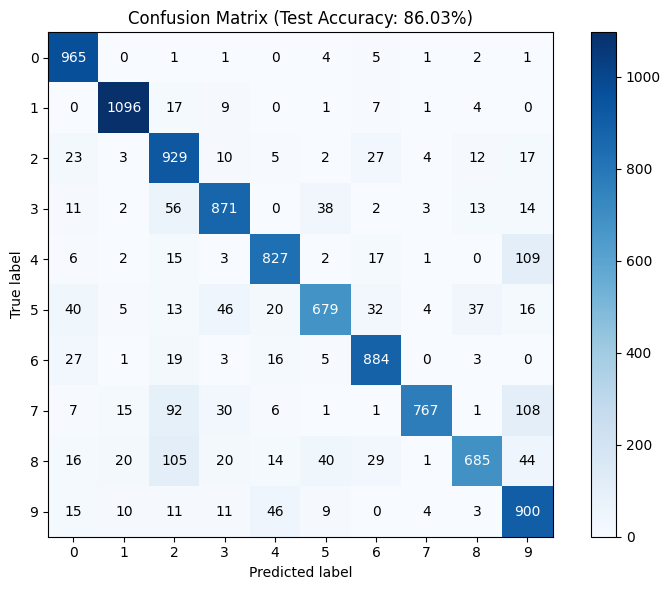

In [1025]:
# --- PO ZAKOŃCZENIU CAŁEGO TRENINGU: pełne metryki na zbiorze testowym ---
print("\n" + "="*60)
print("FINALNA EWALUACJA NA ZBIORZE TESTOWYM")
print("="*60)

def evaluate(NN, X, y_true):
    y_pred = []
    for k in range(len(X)):
        z = NN.z(X[k])[0]
        a = softmax(z)
        y_pred.append(np.argmax(a))
    return accuracy_score(y_true, y_pred), np.array(y_pred)

final_test_acc, y_pred_test = evaluate(NN, x_test, y_test)
print(f"\nTest Accuracy: {final_test_acc:.2%}\n")

print("Classification Report:")
print(classification_report(y_test, y_pred_test, digits=4))

cm = confusion_matrix(y_test, y_pred_test)
print("Confusion Matrix (raw):")
print(cm)

# Wizualizacja confusion matrix
plt.figure(figsize=(8, 6))
plt.imshow(cm, cmap='Blues')
plt.colorbar()
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title(f'Confusion Matrix (Test Accuracy: {final_test_acc:.2%})')
plt.xticks(range(10))
plt.yticks(range(10))

for i in range(10):
    for j in range(10):
        plt.text(j, i, cm[i, j], ha='center', va='center',
                  color='white' if cm[i, j] > cm.max()/2 else 'black')

plt.tight_layout()
plt.show()

In [1026]:
from sklearn.metrics import accuracy_score, classification_report

# y_pred_test musisz mieć już policzone (np. z evaluate())
acc = accuracy_score(y_test, y_pred_test)
print(f"Accuracy: {acc:.2%}\n")

print(classification_report(y_test, y_pred_test, digits=4))

Accuracy: 86.03%

              precision    recall  f1-score   support

           0     0.8694    0.9847    0.9234       980
           1     0.9497    0.9656    0.9576      1135
           2     0.7385    0.9002    0.8114      1032
           3     0.8675    0.8624    0.8649      1010
           4     0.8854    0.8422    0.8633       982
           5     0.8694    0.7612    0.8117       892
           6     0.8805    0.9228    0.9011       958
           7     0.9758    0.7461    0.8456      1028
           8     0.9013    0.7033    0.7901       974
           9     0.7444    0.8920    0.8115      1009

    accuracy                         0.8603     10000
   macro avg     0.8682    0.8580    0.8581     10000
weighted avg     0.8689    0.8603    0.8596     10000
